## 8. Atividade física e sedentarismo

### Objetivo

Esta seção tem como objetivo caracterizar os níveis de **atividade física moderada**, **atividade física vigorosa** e **tempo sedentário** dos participantes.

As variáveis de atividade física representam estimativas de minutos semanais calculadas a partir da frequência e duração informadas pelos participantes. O comportamento sedentário é representado pelo tempo sedentário informado em minutos por dia.

Além de analisar as distribuições dessas variáveis, são investigadas a presença de participantes com zero minutos de atividade, a ocorrência de valores extremos e as relações entre atividade física e comportamento sedentário.

Como essas informações são provenientes de respostas autorreferidas, valores elevados não serão considerados automaticamente erros. As observações originais serão preservadas durante a análise exploratória e eventuais tratamentos serão avaliados posteriormente na preparação para o Machine Learning.

importação de bibliotecas.

In [133]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Identidade visual do HealthSync
COR_PRINCIPAL = "#0E766D"
COR_SECUNDARIA = "#10B981"
COR_TERCIARIA = "#14B8A6"

COR_DESTAQUE = "#F28C82"
COR_NEUTRA = "#94A3B8"

# Cores consistentes para respostas binárias
COR_SIM = COR_PRINCIPAL
COR_NAO = COR_NEUTRA

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

plt.rcParams["figure.dpi"] = 120

In [134]:
CAMINHO_CORE = "../../dataset/healthsync_nhanes_2021_2023_core.csv"

df = pd.read_csv(CAMINHO_CORE)

display(df.head())

,id_participante,peso_estatistico_mec,peso_estatistico_entrevista,psu,estrato_amostral,idade,sexo,imc,pressao_sistolica,pressao_diastolica,...,glicose_jejum,colesterol_total,diabetes_informado,hipertensao_informada,hipertensao_2consultas,colesterol_alto_informado,medicamento_pressao,atv_moderada_min_semana,atv_vigorosa_min_semana,minutos_sedentarios_dia
0,130378.0,54.374.463.898,50.055.450.807,2.0,173.0,43.0,Homem,27.0,132.7,96.0,...,113.0,264.0,Nao,1.0,1.0,0.0,1.0,135.0,135.0,360.0
1,130379.0,34.084.721.548,29.087.450.605,2.0,173.0,66.0,Homem,33.5,117.0,78.7,...,99.0,214.0,Nao,1.0,1.0,0.0,1.0,180.0,135.0,480.0
2,130380.0,81.196.277.992,80.062.674.301,1.0,174.0,44.0,Mulher,29.7,109.0,78.3,...,156.0,187.0,Sim,0.0,NaN,1.0,NaN,20.0,0.0,240.0
3,130386.0,3.998.845.294,3.099.528.261,1.0,179.0,34.0,Homem,30.2,115.0,73.7,...,100.0,183.0,Nao,0.0,NaN,0.0,NaN,30.0,6.9,180.0
4,130387.0,2.077.625.485,19.896.970.559,1.0,181.0,68.0,Mulher,42.6,141.3,76.0,...,NaN,203.0,Nao,1.0,1.0,1.0,1.0,0.0,0.0,1200.0


### 8.1 Resumo das variáveis

**Pergunta da análise:** quais são as principais características das variáveis relacionadas à atividade física e ao comportamento sedentário?

Inicialmente, são analisadas estatísticas descritivas e a disponibilidade das três variáveis. Essa etapa permite comparar suas escalas, tendência central, dispersão e amplitude antes da análise individual das distribuições.

In [135]:

variaveis_atividade = [
    "atv_moderada_min_semana",
    "atv_vigorosa_min_semana",
    "minutos_sedentarios_dia"
]

resumo_atividade = (
    df[variaveis_atividade]
    .describe()
    .T
    .round(2)
)

display(resumo_atividade)

,count,mean,std,min,25%,50%,75%,max
atv_moderada_min_semana,5249.0,219.87,392.58,0.0,20.8,120.0,240.0,6300.0
atv_vigorosa_min_semana,5253.0,69.26,218.05,0.0,0.0,0.0,60.0,5040.0
minutos_sedentarios_dia,5248.0,364.07,207.70,0.0,180.0,300.0,480.0,1380.0


In [136]:

for coluna in variaveis_atividade:
    quantidade = df[coluna].isna().sum()
    percentual = df[coluna].isna().mean() * 100

    print(
        f"{coluna}: {quantidade} ausentes "
        f"({percentual:.2f}%)"
    )

atv_moderada_min_semana: 34 ausentes (0.64%)
atv_vigorosa_min_semana: 30 ausentes (0.57%)
minutos_sedentarios_dia: 35 ausentes (0.66%)


A atividade moderada apresentou média de **219,87 minutos por semana** e mediana de **120 minutos**, enquanto a atividade vigorosa apresentou média de **69,26 minutos por semana** e mediana igual a **0 minuto**.

A diferença entre média e mediana, principalmente nas variáveis de atividade física, indica a presença de distribuições assimétricas e de participantes com valores consideravelmente superiores à região central.

O tempo sedentário apresentou média de **364,07 minutos por dia** e mediana de **300 minutos por dia**.

As três variáveis possuem alta disponibilidade na amostra. Os valores ausentes correspondem a **0,64%** para atividade moderada, **0,57%** para atividade vigorosa e **0,66%** para tempo sedentário.

Os valores máximos de atividade moderada e vigorosa são consideravelmente elevados e serão investigados separadamente antes de qualquer decisão de tratamento.

### 8.2 Participantes com zero minutos de atividade

**Pergunta da análise:** qual proporção dos participantes informou zero minutos semanais de atividade moderada ou vigorosa?

A presença de valores iguais a zero é particularmente importante para compreender a distribuição dessas variáveis, principalmente porque uma grande concentração de zeros pode influenciar medidas como média, mediana, correlação e futuros procedimentos de modelagem.

Os percentuais são calculados considerando apenas os participantes com informação disponível em cada variável.

In [137]:

zero_moderada = (
    df["atv_moderada_min_semana"]
    .eq(0)
    .sum()
)

zero_vigorosa = (
    df["atv_vigorosa_min_semana"]
    .eq(0)
    .sum()
)

validos_moderada = (
    df["atv_moderada_min_semana"]
    .notna()
    .sum()
)

validos_vigorosa = (
    df["atv_vigorosa_min_semana"]
    .notna()
    .sum()
)

pct_zero_moderada = (
    zero_moderada / validos_moderada * 100
)

pct_zero_vigorosa = (
    zero_vigorosa / validos_vigorosa * 100
)

atividade_zero = pd.DataFrame({
    "Tipo de atividade": [
        "Moderada",
        "Vigorosa"
    ],
    "Percentual": [
        pct_zero_moderada,
        pct_zero_vigorosa
    ]
}).round(1)

display(atividade_zero)

,Tipo de atividade,Percentual
0,Moderada,19.4
1,Vigorosa,54.4


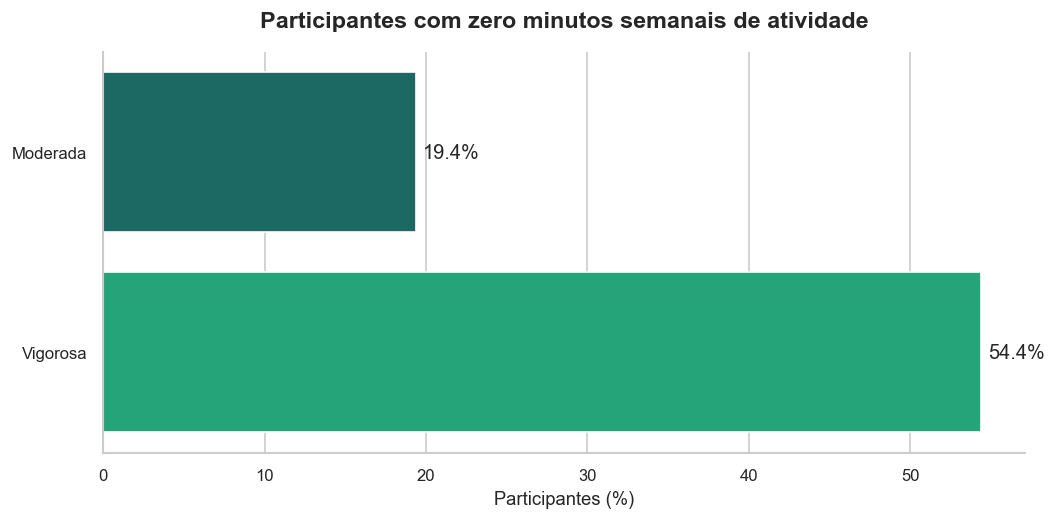

In [138]:
# ============================================================
# PERCENTUAL COM ZERO MINUTOS
# ============================================================

plt.figure(figsize=(9, 4.5))

ax = sns.barplot(
    data=atividade_zero,
    y="Tipo de atividade",
    x="Percentual",
    hue="Tipo de atividade",
    palette={
        "Moderada": COR_PRINCIPAL,
        "Vigorosa": COR_SECUNDARIA
    },
    legend=False
)

plt.title(
    "Participantes com zero minutos semanais de atividade",
    pad=15,
    weight="bold"
)

plt.xlabel("Participantes (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4
    )

sns.despine()

plt.tight_layout()
plt.show()

Entre os participantes com informação disponível, **19,4%** apresentaram zero minutos semanais de atividade moderada, enquanto **54,4%** apresentaram zero minutos de atividade vigorosa.

A concentração de zeros é, portanto, consideravelmente maior na atividade vigorosa. Esse comportamento ajuda a explicar a mediana igual a zero observada anteriormente para essa variável.

Esses valores representam respostas válidas de ausência de atividade registrada e devem ser diferenciados de valores ausentes (`NaN`). Por esse motivo, não serão tratados como dados faltantes.

### 8.3 Distribuição da atividade moderada

**Pergunta da análise:** como os minutos semanais de atividade moderada estão distribuídos entre os participantes?

Como a análise inicial identificou valores elevados, são calculados percentis para compreender melhor a distribuição antes da construção do gráfico.

Para melhorar a visualização da região onde se concentra a maior parte dos participantes, o histograma será apresentado até o **percentil 99 (P99)**.

Esse limite é aplicado exclusivamente à visualização. Os participantes acima do P99 permanecem na base original e continuam disponíveis para as demais análises.

In [139]:
percentis_moderada = (
    df["atv_moderada_min_semana"]
    .quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
    .round(1)
)

display(percentis_moderada)

0.50     120.0
0.75     240.0
0.90     480.0
0.95     840.0
0.99    1800.0
Name: atv_moderada_min_semana, dtype: float64

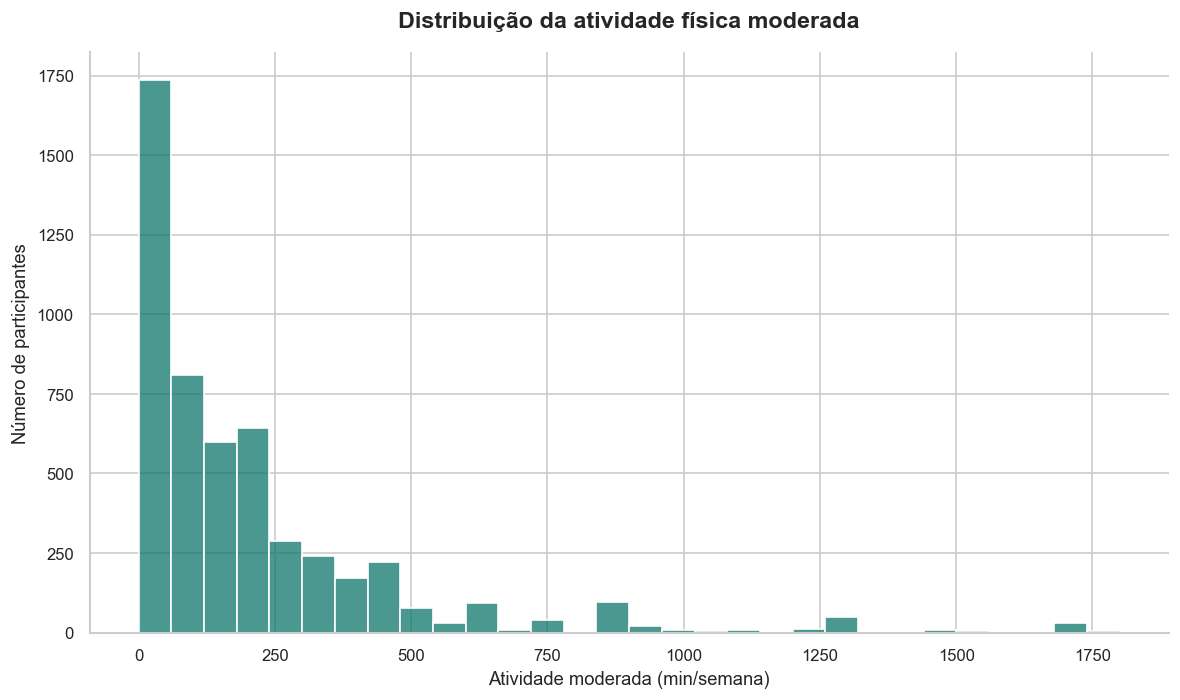

In [140]:
p99_moderada = (
    df["atv_moderada_min_semana"]
    .quantile(0.99)
)

dados_moderada_visual = df[
    df["atv_moderada_min_semana"] <= p99_moderada
]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=dados_moderada_visual,
    x="atv_moderada_min_semana",
    bins=30,
    color=COR_PRINCIPAL,
    edgecolor="white"
)

plt.title(
    "Distribuição da atividade física moderada",
    pad=15,
    weight="bold"
)

plt.xlabel("Atividade moderada (min/semana)")
plt.ylabel("Número de participantes")

sns.despine()

plt.tight_layout()
plt.show()

A mediana da atividade moderada foi de **120 minutos semanais**, enquanto 75% dos participantes apresentaram até **240 minutos** e 90% até **480 minutos** por semana.

O percentil 95 foi de **840 minutos** e o percentil 99 de **1.800 minutos semanais**, mostrando que uma pequena parcela da amostra apresenta valores consideravelmente superiores à região de maior concentração.

O histograma evidencia uma distribuição assimétrica à direita, com maior concentração em valores mais baixos e uma extensão em direção aos valores elevados.

A limitação do eixo ao P99 permite visualizar melhor essa região sem modificar os dados originais.

### 8.4 Distribuição da atividade vigorosa

**Pergunta da análise:** como os minutos semanais de atividade vigorosa estão distribuídos entre os participantes?

A análise anterior mostrou que mais da metade dos participantes apresenta zero minutos de atividade vigorosa. Por esse motivo, espera-se uma concentração elevada no início da distribuição.

Assim como na atividade moderada, o histograma é apresentado até o percentil 99 apenas para melhorar a visualização. Os valores superiores permanecem preservados na base original.

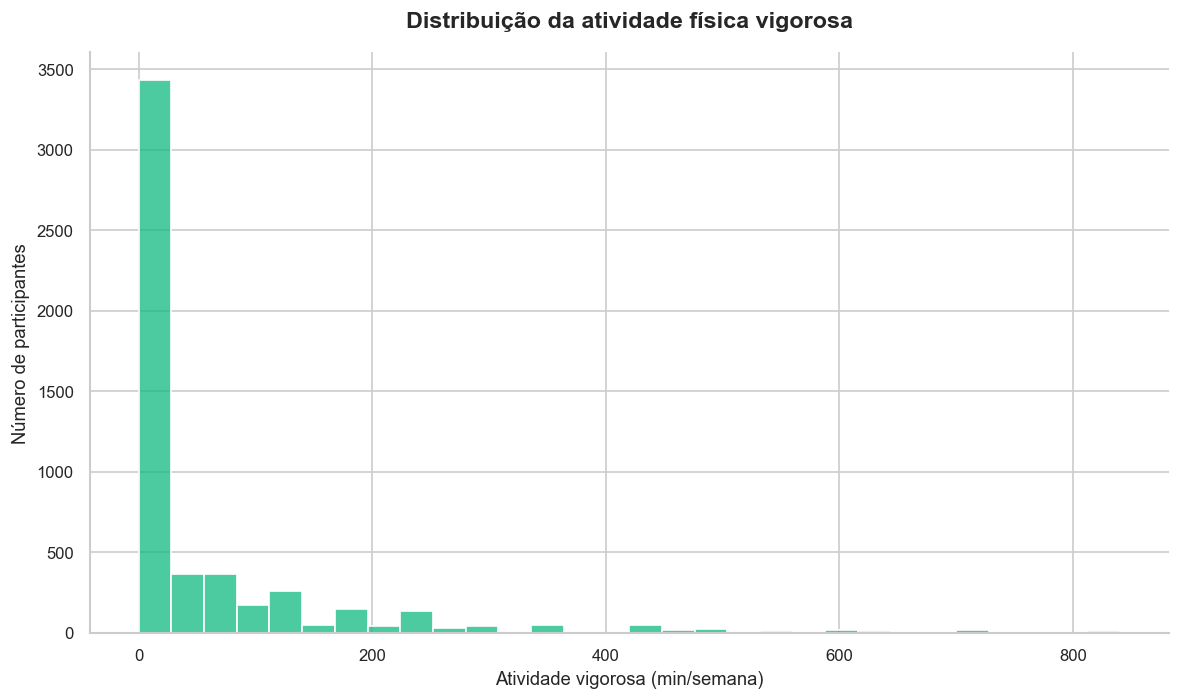

In [141]:
p99_vigorosa = (
    df["atv_vigorosa_min_semana"]
    .quantile(0.99)
)

dados_vigorosa_visual = df[
    df["atv_vigorosa_min_semana"] <= p99_vigorosa
]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=dados_vigorosa_visual,
    x="atv_vigorosa_min_semana",
    bins=30,
    color=COR_SECUNDARIA,
    edgecolor="white"
)

plt.title(
    "Distribuição da atividade física vigorosa",
    pad=15,
    weight="bold"
)

plt.xlabel("Atividade vigorosa (min/semana)")
plt.ylabel("Número de participantes")

sns.despine()

plt.tight_layout()
plt.show()

A distribuição da atividade vigorosa apresenta forte concentração próxima de zero, consistente com a proporção de **54,4% dos participantes com zero minutos semanais** observada anteriormente.

Ao mesmo tempo, existe uma extensão da distribuição em direção a valores elevados. O percentil 99 corresponde a **840 minutos por semana**, indicando que 99% dos valores válidos estão até esse ponto.

Assim como na atividade moderada, a limitação visual ao P99 não representa exclusão ou alteração dos participantes na base original.

### 8.5 Comparação entre atividade moderada e vigorosa

**Pergunta da análise:** como as distribuições da atividade moderada e vigorosa se diferenciam?

O boxplot permite comparar diretamente a tendência central e a dispersão das duas modalidades de atividade física.

Devido à presença de valores muito elevados, a visualização utiliza os dados até o P99 de cada variável. Essa escolha é utilizada apenas para evitar que poucos valores extremos comprimam visualmente as caixas.

Os valores superiores ao P99 permanecem inalterados na base original.

In [142]:
moderada_box = (
    df.loc[
        df["atv_moderada_min_semana"] <= p99_moderada,
        ["atv_moderada_min_semana"]
    ]
    .rename(
        columns={
            "atv_moderada_min_semana": "Minutos"
        }
    )
)

moderada_box["Atividade"] = "Moderada"


vigorosa_box = (
    df.loc[
        df["atv_vigorosa_min_semana"] <= p99_vigorosa,
        ["atv_vigorosa_min_semana"]
    ]
    .rename(
        columns={
            "atv_vigorosa_min_semana": "Minutos"
        }
    )
)

vigorosa_box["Atividade"] = "Vigorosa"


atividade_box = pd.concat(
    [
        moderada_box,
        vigorosa_box
    ],
    ignore_index=True
)

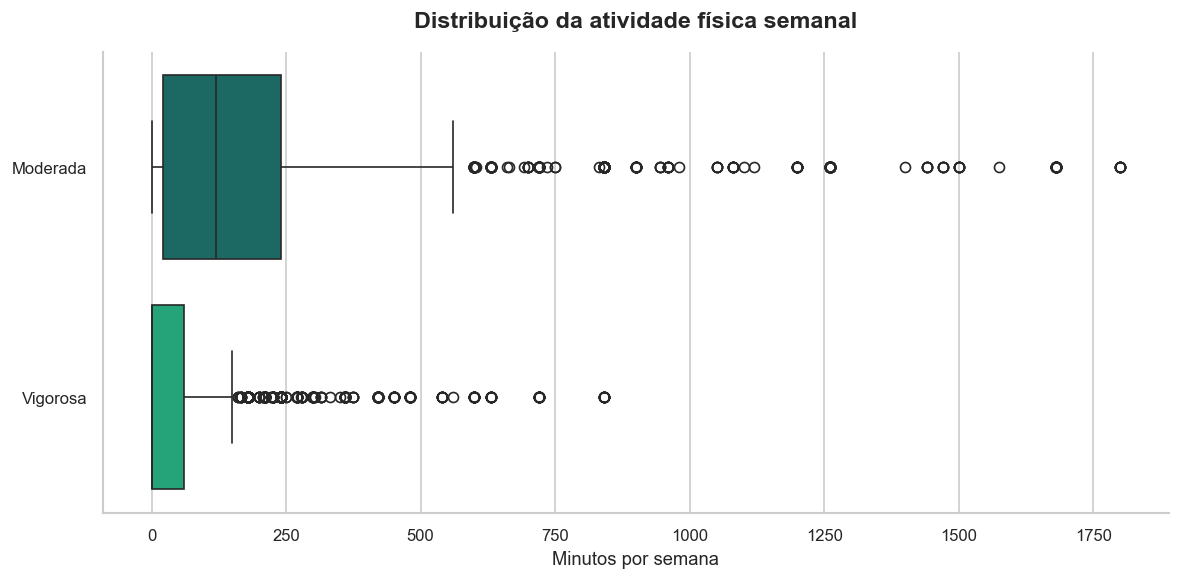

In [143]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=atividade_box,
    y="Atividade",
    x="Minutos",
    hue="Atividade",
    palette={
        "Moderada": COR_PRINCIPAL,
        "Vigorosa": COR_SECUNDARIA
    },
    legend=False
)

plt.title(
    "Distribuição da atividade física semanal",
    pad=15,
    weight="bold"
)

plt.xlabel("Minutos por semana")
plt.ylabel("")

sns.despine()

plt.tight_layout()
plt.show()

A comparação evidencia diferenças importantes entre as duas modalidades.

A atividade moderada apresenta mediana de **120 minutos semanais** e maior distribuição dos participantes acima de zero. A atividade vigorosa, por outro lado, possui mediana igual a **zero**, refletindo a elevada proporção de participantes sem minutos registrados nessa modalidade.

As duas variáveis também apresentam assimetria e valores elevados na extremidade superior, que serão quantificados separadamente.

### 8.6 Quantificação dos valores extremos

**Objetivo:** verificar quantos participantes estão acima do percentil 99 e qual é a magnitude dos maiores valores registrados.

O P99 não é utilizado como critério automático de exclusão. Ele funciona nesta etapa como referência para identificar a pequena parcela da distribuição responsável pelos valores mais elevados.

Em seguida, são inspecionados os maiores registros de atividade moderada e vigorosa para compreender a magnitude dessas observações.

In [144]:
extremos_atividade = pd.DataFrame({
    "Variável": [
        "Atividade moderada",
        "Atividade vigorosa"
    ],
    "P99": [
        p99_moderada,
        p99_vigorosa
    ],
    "Acima do P99": [
        (
            df["atv_moderada_min_semana"]
            > p99_moderada
        ).sum(),
        (
            df["atv_vigorosa_min_semana"]
            > p99_vigorosa
        ).sum()
    ],
    "Máximo": [
        df["atv_moderada_min_semana"].max(),
        df["atv_vigorosa_min_semana"].max()
    ]
})

display(
    extremos_atividade.round(1)
)

,Variável,P99,Acima do P99,Máximo
0,Atividade moderada,1800.0,49,6300.0
1,Atividade vigorosa,840.0,48,5040.0


In [145]:
display(
    df[
        [
            "id_participante",
            "idade",
            "sexo",
            "atv_moderada_min_semana"
        ]
    ]
    .sort_values(
        "atv_moderada_min_semana",
        ascending=False
    )
    .head(10)
)

,id_participante,idade,sexo,atv_moderada_min_semana
4420,140382.0,57.0,Mulher,6300.0
913,132439.0,61.0,Homem,6300.0
3874,139121.0,24.0,Homem,5040.0
2196,135409.0,33.0,Homem,5040.0
3668,138674.0,72.0,Mulher,4410.0
3431,138103.0,60.0,Homem,4200.0
4893,141386.0,60.0,Mulher,4200.0
1667,134173.0,36.0,Homem,4200.0
2445,135966.0,30.0,Mulher,3780.0
1984,134929.0,55.0,Mulher,3780.0


In [146]:
display(
    df[
        [
            "id_participante",
            "idade",
            "sexo",
            "atv_vigorosa_min_semana"
        ]
    ]
    .sort_values(
        "atv_vigorosa_min_semana",
        ascending=False
    )
    .head(10)
)

,id_participante,idade,sexo,atv_vigorosa_min_semana
2912,137009.0,56.0,Mulher,5040.0
618,131741.0,42.0,Homem,4500.0
1098,132870.0,71.0,Homem,3360.0
3960,139308.0,43.0,Mulher,2940.0
3778,138889.0,75.0,Homem,2940.0
566,131642.0,53.0,Mulher,2880.0
5008,141640.0,27.0,Homem,2700.0
1855,134584.0,56.0,Homem,2520.0
3603,138486.0,77.0,Homem,2520.0
2780,136709.0,45.0,Homem,2520.0


Na atividade moderada, **49 participantes** apresentaram valores acima do P99 de **1.800 minutos semanais**, com máximo de **6.300 minutos por semana**.

Na atividade vigorosa, **48 participantes** ficaram acima do P99 de **840 minutos semanais**, com máximo de **5.040 minutos por semana**.

Esses valores são consideravelmente superiores à região central das distribuições. Entretanto, as variáveis foram construídas a partir de frequência e duração autorreferidas pelos participantes, o que pode produzir respostas muito elevadas.

Nesta etapa, não há evidência suficiente para considerar automaticamente esses registros erros. Por esse motivo, os valores originais são preservados.

Eventuais transformações, limitações ou métodos robustos para reduzir a influência dessas observações serão avaliados posteriormente durante a preparação dos dados para Machine Learning.

### 8.7 Tempo sedentário

**Pergunta da análise:** quanto tempo sedentário por dia é informado pelos participantes e como essa variável está distribuída?

Diferentemente das variáveis anteriores, que representam minutos semanais de atividade, o comportamento sedentário é registrado em **minutos por dia**.

São analisados percentis e a distribuição completa da variável para compreender sua tendência central, dispersão e valores mais elevados.

In [147]:
percentis_sedentarismo = (
    df["minutos_sedentarios_dia"]
    .quantile([
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
    .round(1)
)

display(percentis_sedentarismo)

0.25    180.0
0.50    300.0
0.75    480.0
0.90    660.0
0.95    720.0
0.99    960.0
Name: minutos_sedentarios_dia, dtype: float64

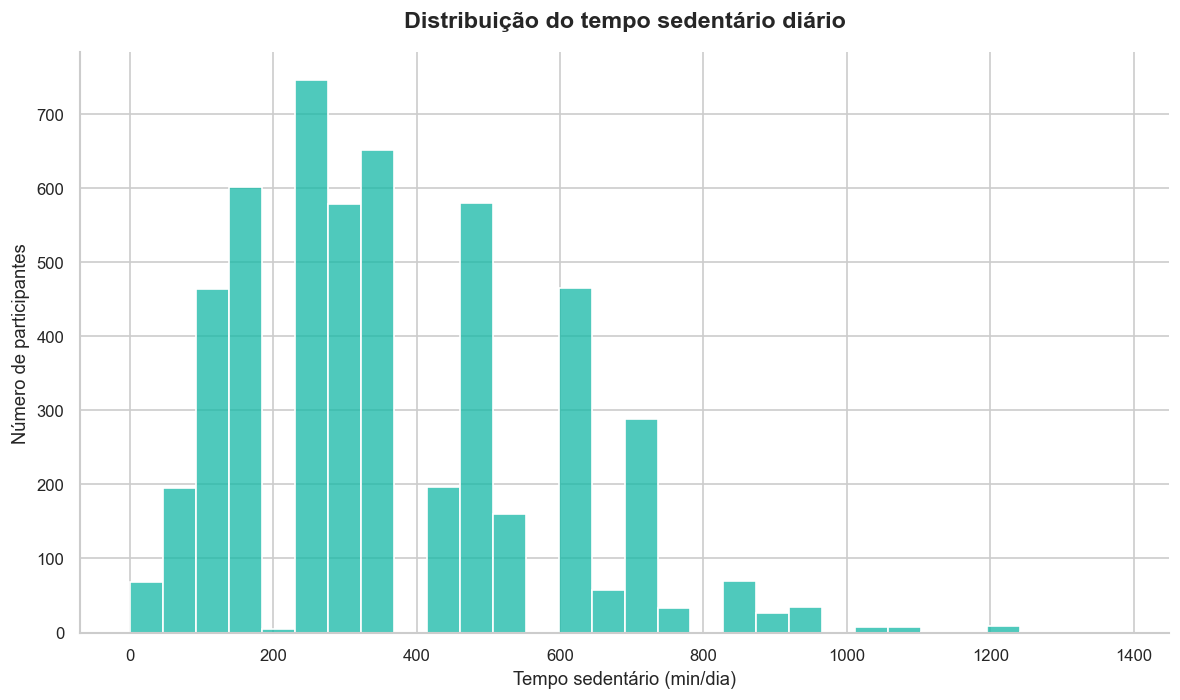

In [148]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="minutos_sedentarios_dia",
    bins=30,
    color=COR_TERCIARIA,
    edgecolor="white"
)

plt.title(
    "Distribuição do tempo sedentário diário",
    pad=15,
    weight="bold"
)

plt.xlabel("Tempo sedentário (min/dia)")
plt.ylabel("Número de participantes")

sns.despine()

plt.tight_layout()
plt.show()

O tempo sedentário apresentou mediana de **300 minutos por dia**, enquanto 25% dos participantes apresentaram até **180 minutos** e 75% até **480 minutos diários**.

Nos percentis superiores, 90% dos participantes apresentaram até **660 minutos**, 95% até **720 minutos** e 99% até **960 minutos por dia**.

O maior valor observado foi de **1.380 minutos por dia**, equivalente a 23 horas. Embora esse valor seja extremo, ele foi preservado nesta etapa, seguindo o mesmo princípio utilizado nas demais variáveis autorreferidas.

### 8.8 Tempo sedentário em horas

Para facilitar a interpretação dos resultados, o tempo sedentário também é convertido de minutos para horas por dia.

Essa transformação é utilizada apenas para apresentação. A variável original em minutos permanece disponível e não é substituída na base.

In [149]:
df["horas_sedentarias_dia"] = (
    df["minutos_sedentarios_dia"] / 60
).round(1)

display(
    df["horas_sedentarias_dia"]
    .describe()
    .round(2)
)

count    5248.00
mean        6.07
std         3.46
min         0.00
25%         3.00
50%         5.00
75%         8.00
max        23.00
Name: horas_sedentarias_dia, dtype: float64

Após a conversão, a mediana corresponde a aproximadamente **5 horas sedentárias por dia**, enquanto a média é de aproximadamente **6,07 horas por dia**.

Metade dos participantes encontra-se aproximadamente entre **3 e 8 horas diárias** de tempo sedentário.

O valor máximo corresponde a **23 horas por dia**, reforçando a presença de respostas extremas que deverão ser consideradas cuidadosamente em etapas posteriores de preparação dos dados.

### 8.9 Relação entre atividade física e sedentarismo

**Pergunta da análise:** participantes que relatam maior quantidade de atividade física apresentam necessariamente menor tempo sedentário?

Atividade física e comportamento sedentário representam dimensões relacionadas ao estilo de vida, mas não devem ser considerados automaticamente comportamentos opostos.

Uma pessoa pode realizar períodos de atividade física e, ainda assim, permanecer sedentária durante várias horas do restante do dia.

Para investigar essa relação na amostra, são calculados os coeficientes de correlação de Pearson entre atividade moderada, atividade vigorosa e tempo sedentário.

In [150]:

corr_atividade_sedentarismo = (
    df[
        [
            "atv_moderada_min_semana",
            "atv_vigorosa_min_semana",
            "minutos_sedentarios_dia"
        ]
    ]
    .corr()
    .round(3)
)

display(corr_atividade_sedentarismo)

,atv_moderada_min_semana,atv_vigorosa_min_semana,minutos_sedentarios_dia
atv_moderada_min_semana,1.000,0.357,-0.121
atv_vigorosa_min_semana,0.357,1.000,-0.078
minutos_sedentarios_dia,-0.121,-0.078,1.000


A atividade moderada e a atividade vigorosa apresentaram correlação positiva de **0,357**, indicando que participantes com maior quantidade registrada de uma modalidade tendem, em alguma medida, a apresentar também maior quantidade da outra.

As associações lineares com o tempo sedentário foram negativas, porém pequenas: **-0,121** para atividade moderada e **-0,078** para atividade vigorosa.

Portanto, na amostra analisada, maiores níveis registrados de atividade física não correspondem necessariamente a reduções proporcionais no tempo sedentário.

Esses resultados reforçam que atividade física e comportamento sedentário fornecem informações diferentes sobre o estilo de vida dos participantes e podem ser consideradas separadamente em análises posteriores.

Os coeficientes representam associações lineares e não permitem estabelecer relações causais entre essas variáveis.

### 8.10 Síntese da atividade física e sedentarismo

As variáveis comportamentais apresentaram características distintas na amostra. A atividade moderada apresentou mediana de **120 minutos semanais**, enquanto a atividade vigorosa apresentou mediana igual a **zero**, acompanhada de uma elevada proporção de participantes sem atividade vigorosa registrada.

As distribuições de atividade física apresentaram assimetria e valores extremos elevados. Esses registros foram preservados durante a EDA, utilizando o P99 apenas como recurso para melhorar a visualização dos gráficos.

O tempo sedentário apresentou mediana equivalente a aproximadamente **5 horas por dia**, também com presença de observações elevadas.

As correlações mostraram associação positiva entre atividade moderada e vigorosa, enquanto as associações lineares entre atividade física e tempo sedentário foram pequenas e negativas.

Esses resultados mostram que as três variáveis representam dimensões complementares do estilo de vida e fornecem informações relevantes para a caracterização dos participantes e para a futura preparação das variáveis utilizadas nos modelos de Machine Learning.